# V3 — the futures basis as an option, priced against a matched swaption

**Citi Research, _US Rates Weekly — Summer lull_, 17 July 2015.** A long futures basis has a floor
of zero on its net basis, so owning it is owning an option. Compare its cost per unit of gamma
against a matched ATMF receiver swaption; buy the basis when it is the cheaper way to own the gamma.

    richness = (sigma_swpt^2 * T) / (net_basis / gamma_basis)     > 1  =>  the basis is cheaper

**READ THIS BEFORE READING ANY P&L.**

1. **The net basis here is mostly NOT switch optionality.** The two-bond crossover sits a median
   ~130bp away, so that option is nearly worthless, while the market net basis is a median ~1.8/32.
   The gamma is therefore a *model* number and the cost a *market* one — which is exactly how the
   note states it, but it means richness is a comparison, not an arbitrage.
2. **The trade is selective, not permanent.** richness > 1 on 8.4% (ZB), 16.8% (ZN), 4.1% (UB) of
   days. Trade counts are small and the significance tests below are the point, not decoration.
3. **Sticky-ATM marking.** The vol cube is ATM-only before 2020-01-24, so a short receiver that has
   drifted off the money is marked with the *current ATM* vol at its *original* strike.
4. **2020-01-24 .. 2020-03-24 has no expiry under 4Y in the cube** — 40 days, exactly COVID. Those
   days are dropped, not bridged.
5. **Arm B's QDB path marks the basis leg only**; the swaption leg is booked at unwind. Totals and
   trade counts agree; the intra-trade QDB path for arm B is the basis leg.


## 0. Setup

In [1]:
%load_ext autoreload
%autoreload 2
import sys, json, warnings, pathlib
warnings.filterwarnings("ignore")
sys.path.insert(0, r"C:\Users\chris\clee\ARBS-bv3")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from dataclasses import replace as _rep
pd.set_option("display.width", 220)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

from RVUtils.BasisVsVol import v3 as V3, analytics as A
from RVUtils.BasisVsVol.build_basis_panel import filter_data_ok

DATA = pathlib.Path(r"C:\Users\chris\clee\ARBS-bv3") / "notebooks" / "backtests" / "basis_vs_vol" / "_data"
RESULTS = DATA.parent / "_results"

def load_panel(root, start="2019-01-01", end="2026-08-11"):
    """Through the SHARED gate. An inline re-implementation is how the notebook and the runner
    came to disagree about which days exist, and it left is_roll stale after rows were dropped."""
    raw = pd.read_parquet(DATA / f"v3_panel_{root}.parquet")
    raw["date"] = pd.to_datetime(raw["date"])
    raw = raw[(raw["date"] >= start) & (raw["date"] <= end)]
    p = filter_data_ok(raw, require=True)
    print(f"{root}: {len(raw)} rows -> {len(p)} pass the gate, {int(p['richness'].notna().sum())} with a richness")
    return p

PANELS = {r: load_panel(r) for r in ("ZB", "ZN", "UB")}


ZB: 1905 rows -> 1837 pass the gate, 1830 with a richness
ZN: 1902 rows -> 1896 pass the gate, 1889 with a richness
UB: 1884 rows -> 1879 pass the gate, 1872 with a richness


## 1. CONFIG — the only cell you need to edit

In [2]:
CONFIG = dict(
    # ---- what to trade -------------------------------------------------------------
    root                = "UB",     # ZB | ZN | UB
    arm                 = "B",      # A = long basis outright; B = + short matched receiver; C = ablation
    # ---- signal --------------------------------------------------------------------
    entry_richness      = 1.10,     # enter when the basis is this many times cheaper per unit gamma
    exit_richness       = 1.00,     # exit at fair value
    max_hold_days       = 10,
    take_profit_ticks   = 4.0,      # None to disable
    stop_ticks          = None,
    entry_net_basis_ticks = 6.0,    # arm C only: "cheap net basis", no vol leg
    # ---- guards: FIXED by pre-registration, not knobs ------------------------------
    min_net_basis_ticks = 1.0,
    min_gamma           = 1e-5,
    dtd_min             = 21,
    dtd_max             = 120,
    # ---- mechanics -----------------------------------------------------------------
    exec_lag_days       = 1,
    max_gap_days        = 5,
    # ---- sizing / costs -------------------------------------------------------------
    face_mm             = 100.0,    # $mm of CTD face
    cost_32nds          = 0.5,      # basis round trip, 32nds
    swaption_cost_vol_bp= 0.25,     # swaption round trip, normal bp of vol
    cost_mult           = 1.0,
)

CFG = V3.V3Config(**CONFIG)
RES = V3.run_v3(PANELS[CFG.root], CFG)
print(CFG.key())
print(f"{len(RES.trades)} trades over {len(RES.daily)} days")

UB/B/e1.1/x1/h10/tp4/cm1
15 trades over 1879 days


## 2. Known-answer gate — the note's own numbers

In [3]:
# The note's own arithmetic, as literals. If this cell fails, nothing below is worth reading.
NOTE = dict(face_mm=100.0, net_basis_ticks=4.2, basis_cost_usd=130_000.0,
            gamma_usd=420.0, swaption_cost_usd=187_000.0, stated_ratio=1.4)

cost_from_ticks = NOTE["net_basis_ticks"] * V3.TICK_USD_PER_MM * NOTE["face_mm"]
ratio = NOTE["swaption_cost_usd"] / NOTE["basis_cost_usd"]
cpg_basis = NOTE["basis_cost_usd"] / NOTE["gamma_usd"]
cpg_swpt  = NOTE["swaption_cost_usd"] / NOTE["gamma_usd"]

chk = pd.DataFrame([
    ("4.2 ticks on $100mm -> $",      cost_from_ticks, 130_000.0, abs(cost_from_ticks - 130_000) < 1_500),
    ("swaption/basis cost ratio",      ratio,           1.4,       abs(ratio - 1.4) < 0.05),
    ("basis cost per unit gamma",      cpg_basis,       309.5,     abs(cpg_basis - 309.5) < 1.0),
    ("swaption cost per unit gamma",   cpg_swpt,        445.2,     abs(cpg_swpt - 445.2) < 1.0),
    ("richness = cpg_swpt / cpg_basis",cpg_swpt/cpg_basis, 1.4,    abs(cpg_swpt/cpg_basis - 1.4) < 0.05),
], columns=["check", "computed", "note", "ok"])
display(chk.style.format({"computed": "{:,.4f}", "note": "{:,.4f}"}))
assert bool(chk["ok"].all()), "the note's own arithmetic does not reproduce"

# and the closed form the whole comparison rests on: cost/gamma of an ATMF normal swaption is sigma^2 T
from RVUtils.BasisVsVol.bachelier import normal_atm_price, normal_gamma
sig, T = 90.0, 0.5
lhs = float(normal_atm_price(sig, T)) / float(normal_gamma(0.0, 0.0, sig, T))
assert abs(lhs - sig**2 * T) < 1e-6, (lhs, sig**2 * T)
print(f"GATE PASSED: cost/gamma = sigma^2*T verified against bachelier.py ({lhs:.1f} == {sig**2*T:.1f} bp^2)")
print("             the note's 1.4x reproduces from its own stated inputs")


,check,computed,note,ok
0,4.2 ticks on $100mm -> $,"131,250.0000","130,000.0000",True
1,swaption/basis cost ratio,1.4385,1.4000,True
2,basis cost per unit gamma,309.5238,309.5000,True
3,swaption cost per unit gamma,445.2381,445.2000,True
4,richness = cpg_swpt / cpg_basis,1.4385,1.4000,True


GATE PASSED: cost/gamma = sigma^2*T verified against bachelier.py (4050.0 == 4050.0 bp^2)
             the note's 1.4x reproduces from its own stated inputs


## 3. Data-quality funnel

In [4]:
p = RES.panel
rows = [("panel days", len(p)),
        ("  rolls", int(p["is_roll"].sum()) if "is_roll" in p else 0),
        ("  with a swaption vol", int(p["swaption_vol_bp"].notna().sum())),
        ("  with a forward rate", int(p["forward_rate"].notna().sum())),
        ("  with a richness", int(p["richness"].notna().sum())),
        ("  eligible to enter", int(p["eligible"].sum())),
        ("  richness > entry", int((p["richness"] >= CFG.entry_richness).sum())),
        ("trades", len(RES.trades))]
display(pd.DataFrame(rows, columns=["stage", "n"]))
print(f"|crossover| < 25bp on {100*(p['crossover_bp'].abs() < 25).mean():.1f}% of days")
print(f"median richness {p['richness'].median():.4f} | >1 on {100*(p['richness'] > 1).mean():.1f}% of days")

,stage,n
0,panel days,1879
1,rolls,30
2,with a swaption vol,1872
3,with a forward rate,1877
4,with a richness,1872
5,eligible to enter,714
6,richness > entry,66
7,trades,15


|crossover| < 25bp on 29.9% of days
median richness 0.0000 | >1 on 3.9% of days


## 4. Performance

,value
n_days,1879.0000
days_in_pos,31.0000
total_volbp,-10.7597
ann_volbp,-1.4430
ann_vol,6.2790
sharpe,-0.2298
t_naive,-0.6277
t_nw,-0.6827
nw_lags,1.0000
max_dd_volbp,-20.5870


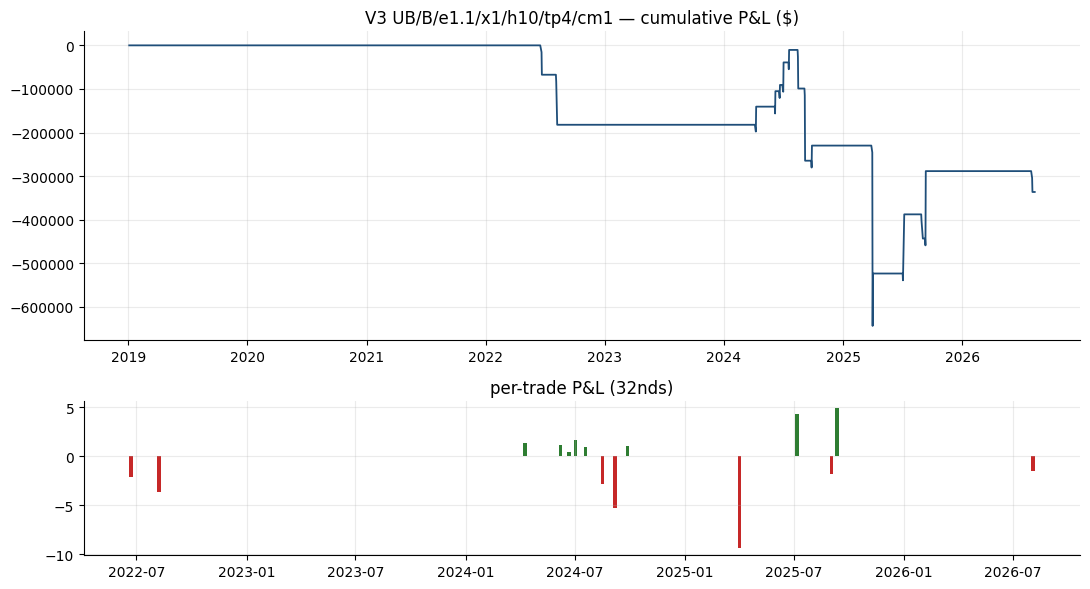

,count,mean,sum
reason,,,
signal,13,-1.542,-20.049
take_profit,2,4.645,9.289


In [5]:
s = A.summarize(RES.daily, RES.trades)
display(pd.Series(s).to_frame("value").style.format(precision=4))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), height_ratios=[2, 1], sharex=False)
ax1.plot(RES.daily.index, RES.daily["equity"], lw=1.3, color="#1f4e79")
ax1.set_title(f"V3 {CFG.key()} — cumulative P&L ($)")
if len(RES.trades):
    t = RES.trades.copy(); t["exit_date"] = pd.to_datetime(t["exit_date"])
    ax2.bar(t["exit_date"], t["pnl_volbp"], width=6,
            color=["#2e7d32" if v > 0 else "#c62828" for v in t["pnl_volbp"]])
    ax2.set_title("per-trade P&L (32nds)")
plt.tight_layout(); plt.show()

if len(RES.trades):
    display(RES.trades.groupby("reason")["pnl_volbp"].agg(["count", "mean", "sum"]).round(3))

## 5. The cost-per-gamma decomposition — the section that can kill the study on its own

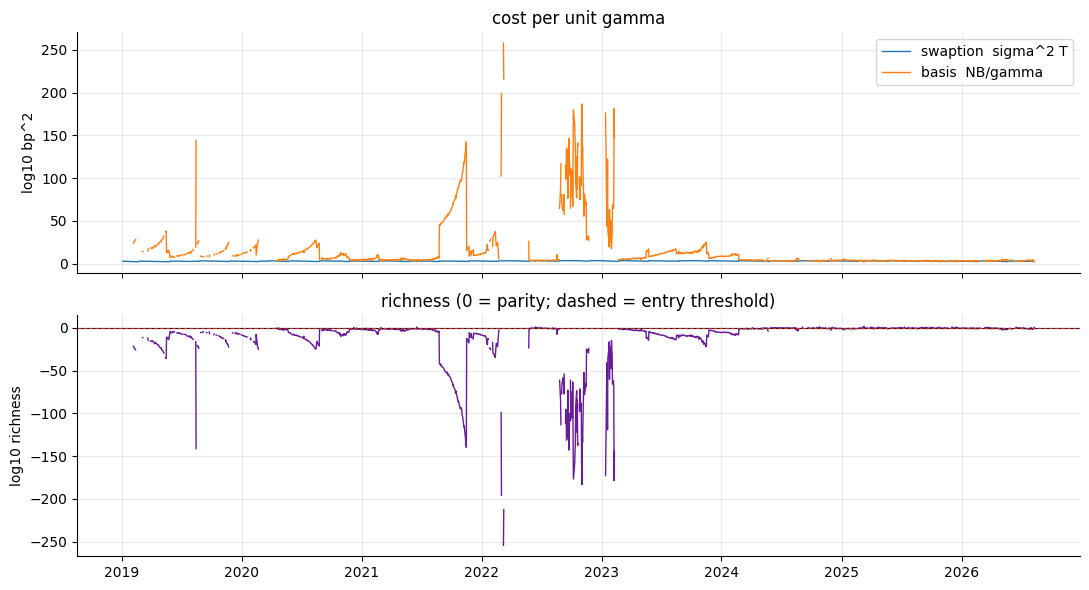

347 of 1879 days have a non-positive or infinite basis cost-per-gamma, omitted above


,total $
pnl_basis,"124,563"
pnl_swaption,"7,946"
fees,"468,751"
pnl,"-336,242"


Does the swaption leg do any work? Compare pnl_basis with pnl_swaption above.


In [6]:
# Plot LOG10 of the values on a linear axis rather than using a log axis. The ratio spans ~60
# orders of magnitude -- the net basis divided by a near-zero model gamma is astronomically large --
# and matplotlib's log tick locator raises OverflowError on a range that wide. Taking the log
# ourselves keeps the shape and cannot overflow.
def _l10(x):
    x = pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan)
    return np.log10(x.where(x > 0))

_b = pd.to_numeric(p["basis_cpg"], errors="coerce")
n_bad = int(((_b <= 0) | ~np.isfinite(_b)).sum())

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
a1.plot(p["date"], _l10(p["swaption_cpg"]), lw=1.0, label="swaption  sigma^2 T")
a1.plot(p["date"], _l10(p["basis_cpg"]), lw=1.0, label="basis  NB/gamma")
a1.set_ylabel("log10 bp^2"); a1.set_title("cost per unit gamma"); a1.legend()
a2.plot(p["date"], _l10(p["richness"]), lw=1.0, color="#6a1b9a")
a2.axhline(0.0, color="k", lw=.8)
a2.axhline(np.log10(CFG.entry_richness), color="#c62828", lw=.8, ls="--")
a2.set_ylabel("log10 richness"); a2.set_title("richness (0 = parity; dashed = entry threshold)")
plt.tight_layout(); plt.show()
print(f"{n_bad} of {len(p)} days have a non-positive or infinite basis cost-per-gamma, omitted above")

if CFG.arm == "B" and "pnl_swaption" in RES.trades.columns and len(RES.trades):
    leg = RES.trades[["pnl_basis", "pnl_swaption", "fees", "pnl"]].sum().to_frame("total $")
    display(leg.style.format("{:,.0f}"))
    print("Does the swaption leg do any work? Compare pnl_basis with pnl_swaption above.")

## 6. Knob sweeps

,root,arm,entry,hold,n,sharpe,total
28,ZB,C,1.25,21,59,-0.114,-20.604
26,ZB,C,1.10,42,59,-0.114,-20.604
34,ZB,C,2.00,21,59,-0.114,-20.604
35,ZB,C,2.00,42,59,-0.114,-20.604
32,ZB,C,1.50,42,59,-0.114,-20.604
31,ZB,C,1.50,21,59,-0.114,-20.604
29,ZB,C,1.25,42,59,-0.114,-20.604
25,ZB,C,1.10,21,59,-0.114,-20.604
24,ZB,C,1.10,10,64,-0.190,-33.889
27,ZB,C,1.25,10,64,-0.190,-33.889


cells 102 | positive 0% | median -0.616


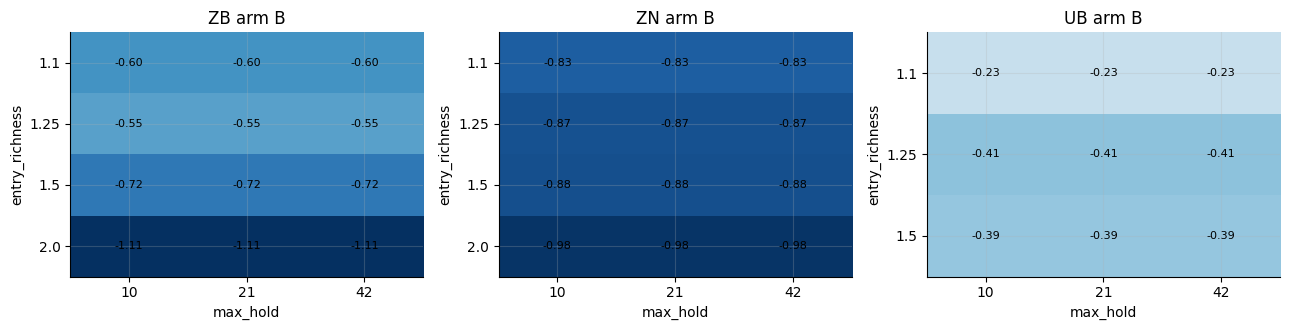

In [7]:
rows = []
for root, pan in PANELS.items():
    for arm in ("A", "B", "C"):
        for er in (1.10, 1.25, 1.50, 2.00):
            for mh in (10, 21, 42):
                r_ = V3.run_v3(pan, _rep(CFG, root=root, arm=arm, entry_richness=er, max_hold_days=mh))
                if r_.trades.empty:
                    continue
                st = A.summarize(r_.daily, r_.trades)
                rows.append(dict(root=root, arm=arm, entry=er, hold=mh,
                                 n=int(st["n_trades"]), sharpe=st["sharpe"], total=st["total_volbp"]))
SWEEP = pd.DataFrame(rows)
display(SWEEP.sort_values("sharpe", ascending=False).head(15).round(3))
print(f"cells {len(SWEEP)} | positive {100*(SWEEP['sharpe']>0).mean():.0f}% | median {SWEEP['sharpe'].median():.3f}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, root in zip(axes, PANELS):
    sub = SWEEP[(SWEEP["root"] == root) & (SWEEP["arm"] == CFG.arm)]
    if sub.empty: continue
    m = sub.pivot_table(index="entry", columns="hold", values="sharpe")
    im = ax.imshow(m.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(m.columns)), m.columns); ax.set_yticks(range(len(m.index)), m.index)
    ax.set_title(f"{root} arm {CFG.arm}"); ax.set_xlabel("max_hold"); ax.set_ylabel("entry_richness")
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            ax.text(j, i, f"{m.values[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.tight_layout(); plt.show()

## 7. Cost curve and break-even

In [8]:
lad = []
for cm in (0.0, 0.5, 1.0, 1.5, 2.0, 3.0):
    r_ = V3.run_v3(PANELS[CFG.root], _rep(CFG, cost_mult=cm))
    if r_.trades.empty: continue
    st = A.summarize(r_.daily, r_.trades); st["cost_mult"] = cm; lad.append(st)
LAD = pd.DataFrame(lad)
display(LAD[["cost_mult", "n_trades", "total_volbp", "sharpe"]].round(3))
alive = LAD[LAD["sharpe"] > 0]["cost_mult"]
print(f"break-even cost multiple: {alive.max():.2f}x" if len(alive) else "never positive at any cost level")

,cost_mult,n_trades,total_volbp,sharpe
0,0.0,15,4.24,0.089
1,0.5,15,-3.26,-0.069
2,1.0,15,-10.76,-0.230
3,1.5,15,-18.26,-0.389
4,2.0,15,-25.76,-0.545
5,3.0,15,-40.76,-0.835


break-even cost multiple: 0.00x


## 8. Ablation — does the swaption comparison do any work?

In [9]:
abl = []
for lbl, arm in (("A: long basis, richness signal", "A"),
                 ("B: basis vs swaption (RV)", "B"),
                 ("C: cheap net basis only (no vol leg)", "C")):
    r_ = V3.run_v3(PANELS[CFG.root], _rep(CFG, arm=arm))
    if r_.trades.empty:
        abl.append(dict(model=lbl, n_trades=0, sharpe=np.nan)); continue
    st = A.summarize(r_.daily, r_.trades); st["model"] = lbl; abl.append(st)
display(pd.DataFrame(abl)[["model", "n_trades", "hit_rate", "total_volbp", "sharpe", "t_nw"]].round(3))
print("If C matches A/B, the swaption comparison is decoration and the honest name is 'buy cheap basis'.")

,model,n_trades,hit_rate,total_volbp,sharpe,t_nw
0,"A: long basis, richness signal",15,0.467,-11.014,-0.246,-0.724
1,B: basis vs swaption (RV),15,0.533,-10.760,-0.230,-0.683
2,C: cheap net basis only (no vol leg),119,0.437,-125.004,-0.395,-1.181


If C matches A/B, the swaption comparison is decoration and the honest name is 'buy cheap basis'.


## 9. Permutation and the deflated Sharpe

In [10]:
rng = np.random.default_rng(20260814)
tp = RES.trades["pnl_volbp"].to_numpy(float)
obs = float(tp.sum())
draws = np.array([float((tp * rng.choice([-1.0, 1.0], size=tp.size)).sum()) for _ in range(2000)])
pct = float((draws < obs).mean())
n_trials = int(len(SWEEP))
var = float(pd.to_numeric(SWEEP["sharpe"]).var(ddof=1))
emax = A.expected_max_sharpe(n_trials, var)
dsr = A.deflated_sharpe(RES.daily["pnl_volbp"], n_trials, var)
lo, hi = A.block_bootstrap_ci(RES.daily["pnl_volbp"], block=21, n_boot=2000)
conc = A.concentration(RES.trades["pnl_volbp"])
ALIVE = (dsr > 0.95) and (conc["top3_share"] < 0.60) and (pct > 0.95)
display(pd.Series({"sharpe": s["sharpe"], "t_nw": s.get("t_nw"), "n_trials": n_trials,
                   "E[max|null]": emax, "deflated_sharpe": dsr, "perm_pct": pct,
                   "top3_share": conc["top3_share"], "ci95_lo": lo, "ci95_hi": hi}).to_frame("value").style.format(precision=4))
print(f"ALIVE = {ALIVE}")

,value
sharpe,-0.2298
t_nw,-0.6827
n_trials,102.0000
E[max|null],0.6931
deflated_sharpe,0.0024
perm_pct,0.2335
top3_share,-1.0170
ci95_lo,-0.7349
ci95_hi,0.4619


ALIVE = False


## 10. Regime split

In [11]:
display(A.regime_split(RES.daily, col="pnl_volbp", by="year").round(3))

,period,n_days,total_volbp,sharpe
0,2019,241,0.000,NaN
1,2020,248,0.000,NaN
2,2021,251,0.000,NaN
3,2022,247,-5.827,-1.619
4,2023,242,0.000,NaN
5,2024,247,-1.527,-0.226
6,2025,249,-1.874,-0.123
7,2026,154,-1.531,-1.713


## 11. QueryDrivenBacktest cross-check

QDB final            -336,241.27
reference final      -336,241.90
difference                0.6332
closed positions 15 vs 15 reference trades


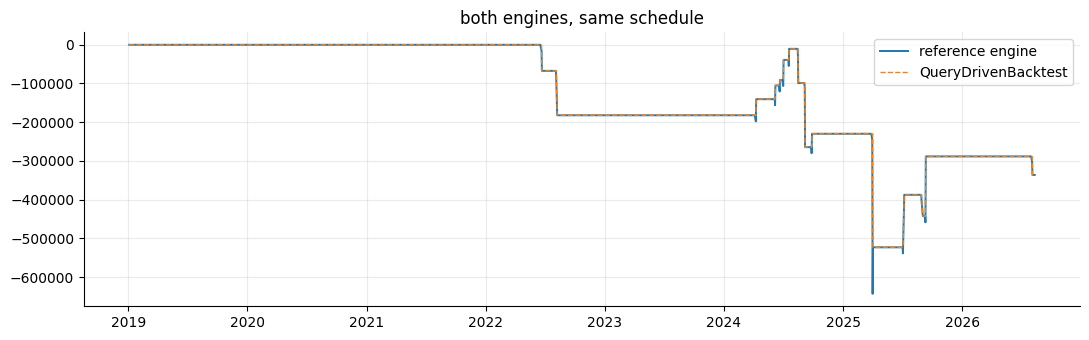

In [12]:
from BT.signals.basis_swaption import run_v3_qdb, qdb_equity
bt, ref = run_v3_qdb(PANELS[CFG.root], CFG)
eq = qdb_equity(bt); refeq = ref.daily["equity"].astype(float)
print(f"QDB final       {eq.iloc[-1]:>16,.2f}")
print(f"reference final {refeq.iloc[-1]:>16,.2f}")
print(f"difference      {abs(eq.iloc[-1]-refeq.iloc[-1]):>16,.4f}")
print(f"closed positions {len(bt.portfolio.closed_positions_log)} vs {len(ref.trades)} reference trades")
assert len(bt.portfolio.closed_positions_log) == len(ref.trades), "trade counts disagree"
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(refeq.index, refeq.values, lw=1.4, label="reference engine")
ax.plot(eq.index, eq.values, lw=1.0, ls="--", label="QueryDrivenBacktest")
ax.legend(); ax.set_title("both engines, same schedule"); plt.tight_layout(); plt.show()

## 12. How to read this

| § | question |
|---|---|
| 2 | does the machine reproduce the note's own arithmetic? |
| 3 | how many days survive, and how selective is the signal? |
| 4 | what did it make? |
| 5 | is the basis actually cheaper per unit gamma, and does the swaption leg do work? |
| 6 | is the result a level across the surface, or one lucky cell? |
| 7 | do costs bind? |
| 8 | **does the swaption comparison add anything over "buy cheap basis"?** |
| 9 | does it survive its own trial count? |
| 11 | do the two engines agree? |

**Kill conditions, pre-registered.** Alive requires ALL of: deflated Sharpe > 0.95 against the full
trial count; survives 2× costs; sign-flip permutation percentile > 0.95; top-3 trade share < 0.60;
and the ablation must not match.
